### Exploring Hawaii

Data for the Hawaiian islands is in the standard file for the 50 states plus DC and Puerto Rico.

In [216]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt

user = os.path.expanduser("~")
dbpath = user + '/data/'
fn = 'gz_2010_us_040_00_5m'
gdf = gpd.read_file(dbpath+fn)
gdf.shape

(52, 6)

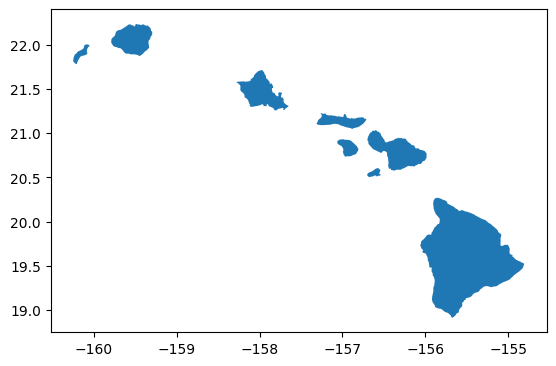

In [217]:
sel = gdf['NAME'] == 'Hawaii'
hawaii = gdf[sel]
hawaii.plot()
plt.show()

In [218]:
hawaii.shape

(1, 6)

So there is only one row of data for Hawaii, but 9 islands.  Possibly there are more sophisticated ways to do this, but one approach is as follows.

In [219]:
MP = hawaii.geometry.iloc[0]

`0` is the only valid index into `hawaii.geometry`.  `MP` is a `shapely` MULTIPOLYGON.

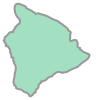

In [220]:
MP.geoms[0]

In [221]:
MP.geoms

In [222]:
islands_mp = list(MP.geoms)
len(islands_mp)

9

`islands_mp` is an array (`list`) of POLYGON objects.  The elements are not identified in the data.  

One way to figure them out is to obtain points from Google Maps.

In [223]:
D = {"Hawaii":[-155.519783,19.625055], 
     "Kaho'olawe":[-156.607857,20.550829],
     "Kauai":[-159.567160,22.017814],
     "Lanai":[-156.930387,20.834303],
     "Maui":[-156.279557,20.758340],
     "Molokai":[-156.986996,21.134644],
     "Ni'ihau":[-160.148047,21.904692],
     "O'ahu":[-157.968125,21.488976],
     "Ford Island":[-157.959627,21.363596]}

In [224]:
from shapely import Point

rL = list()
for i,pg in enumerate(islands_mp):
    for k,v in D.items():
        if pg.contains(Point(v)):
            rL.append((i,k))

for t in rL:
    print(t)

(0, 'Hawaii')
(2, "Ni'ihau")
(3, 'Kauai')
(4, 'Molokai')
(5, "Kaho'olawe")
(6, 'Maui')
(7, 'Lanai')
(8, "O'ahu")
(8, 'Ford Island')


That looks good, except there is an issue with Ford Island.  That's not too surprising, since Ford Island is in the harbor at Honolulu, Oahu.  Here is another approach.  Let's also use another method to extract the individual islands.

In [225]:
gs = hawaii.geometry  # gs is a GeoSeries
islands_gs = gs.explode(index_parts=True) # still a GeoSeries

L = list(range(9)) # trick to get an index inside apply
def f(p):
    #x,y = p.representative_point().coords[:][0]
    x = p.centroid.x
    y = p.centroid.y
    index = L.pop(0)
    plt.annotate(
        text=str(index),
        xy=(x,y))

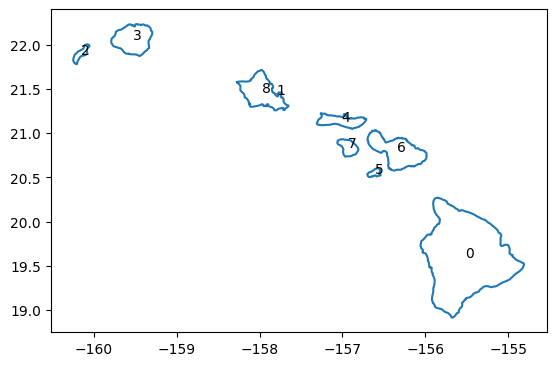

In [226]:
fig,ax = plt.subplots()
islands_gs.boundary.plot(ax=ax)
islands_gs.apply(f)   
plt.show()

We will make the entries for a column of island names by manually massaging `rL` from above.  The question is whether it is Ford Island or O'ahu that should be item1.

I wanted to use `.area()` to decide this question, but GeoPandas is giving me an error about CRS, even after I do `islands_gdf = islands_gdf.to_crs(hawaii.crs)`.

Instead I simply search with the first point of polygon 1 on Google Maps (remembering to reverse and put latitude first).  The result is off the north shore.  So I can assign polygon 1 to Oahu.

In [227]:
islands_gs

11  0    POLYGON ((-155.77823 20.24574, -155.77273 20.2...
    1    POLYGON ((-157.78958 21.4384, -157.78973 21.43...
    2    POLYGON ((-160.125 21.95909, -160.12226 21.962...
    3    POLYGON ((-159.43171 22.22002, -159.40732 22.2...
    4    POLYGON ((-157.01455 21.1855, -156.99911 21.18...
    5    POLYGON ((-156.54417 20.5228, -156.55002 20.52...
    6    POLYGON ((-156.61201 21.02477, -156.61206 21.0...
    7    POLYGON ((-157.01 20.92976, -156.98981 20.9321...
    8    POLYGON ((-158.04449 21.30601, -158.0883 21.29...
Name: geometry, dtype: geometry

In [228]:
names = [t[1] for t in rL]
ford = names.pop()
oahu = names.pop()
names.insert(1,oahu)
names.append(ford)
names

['Hawaii',
 "O'ahu",
 "Ni'ihau",
 'Kauai',
 'Molokai',
 "Kaho'olawe",
 'Maui',
 'Lanai',
 'Ford Island']

Annotating in the "proper" way would involve making a column.  GeoPandas is complaining about the crs even though `islands_gs` has one and even if a set it again.

So, let's just reuse the code from above.

In [229]:
L = list(range(9))

def f(p):
    #x,y = p.representative_point().coords[:][0]
    x = p.centroid.x
    y = p.centroid.y
    index = L.pop(0)
    plt.annotate(
        text=names[index],
        xy=(x,y))

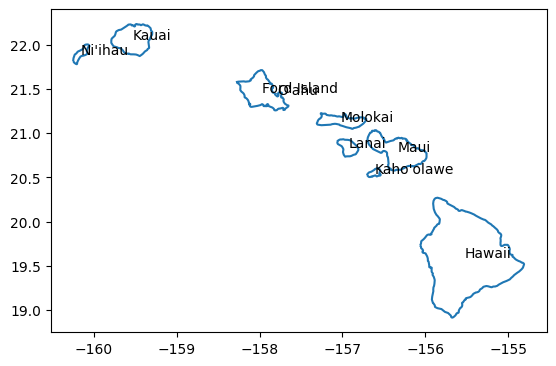

In [230]:
fig,ax = plt.subplots()
islands_gs.boundary.plot(ax=ax)
islands_gs.apply(f)   
plt.show()

The fussy part is then to adjust positions for the names.  You can find that in a script in the Hawaii folder.  Just adjust `x` and `y` inside `f` based on the name.

One last thing is to get some nice colors.

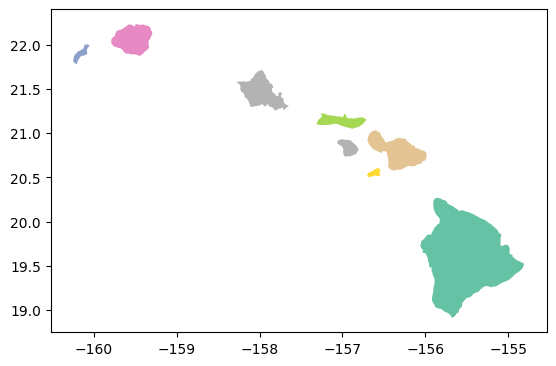

In [231]:
islands_gs.plot(cmap='Set2')
plt.show()